In [1]:
from google.colab import files

files.upload()

Saving PetImages_Small.zip to PetImages_Small.zip


In [2]:
import zipfile

with zipfile.ZipFile("PetImages_Small.zip","r") as zip_ref:
    zip_ref.extractall("/content/")

In [3]:
import zipfile

with zipfile.ZipFile('/content/PetImages_Small.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')


In [4]:
import os

print(os.listdir('/content'))

['.config', 'PetImages_Small\\Cat\\11210.jpg', 'PetImages_Small\\Dog\\10748.jpg', 'PetImages_Small\\Cat\\12470.jpg', 'PetImages_Small\\Dog\\1059.jpg', 'PetImages_Small\\Cat\\10368.jpg', 'PetImages_Small\\Dog\\12000.jpg', 'PetImages_Small\\Dog\\10412.jpg', 'PetImages_Small\\Dog\\10303.jpg', 'PetImages_Small\\Cat\\11634.jpg', 'PetImages_Small\\Cat\\2682.jpg', 'PetImages_Small\\Dog\\12464.jpg', 'PetImages_Small\\Dog\\261.jpg', 'PetImages_Small\\Cat\\2381.jpg', 'PetImages_Small\\Dog\\12254.jpg', 'PetImages_Small\\Cat\\10536.jpg', 'PetImages_Small\\Dog\\10535.jpg', 'PetImages_Small\\Cat\\11355.jpg', 'PetImages_Small\\Cat\\2059.jpg', 'PetImages_Small\\Dog\\10928.jpg', 'PetImages_Small\\Cat\\11490.jpg', 'PetImages_Small\\Cat\\1449.jpg', 'PetImages_Small\\Cat\\11861.jpg', 'PetImages_Small\\Cat\\1343.jpg', 'PetImages_Small\\Dog\\12372.jpg', 'PetImages_Small\\Cat\\11227.jpg', 'PetImages_Small\\Cat\\2545.jpg', 'PetImages_Small\\Cat\\11265.jpg', 'PetImages_Small\\Cat\\11206.jpg', 'PetImages_Small\

In [5]:
import os
import shutil

os.makedirs("/content/PetImages_Small/Cat", exist_ok=True)
os.makedirs("/content/PetImages_Small/Dog", exist_ok=True)

for file in os.listdir("/content"):

    if file.startswith("PetImages_Small\\Cat\\"):

        new_name = file.split("\\")[-1]

        shutil.move(
            os.path.join("/content", file),
            os.path.join("/content/PetImages_Small/Cat", new_name)
        )

    elif file.startswith("PetImages_Small\\Dog\\"):

        new_name = file.split("\\")[-1]

        shutil.move(
            os.path.join("/content", file),
            os.path.join("/content/PetImages_Small/Dog", new_name)
        )

print("Dataset fixed successfully!")

Dataset fixed successfully!


In [6]:
import os

print(os.listdir("/content/PetImages_Small"))

['Cat', 'Dog']


In [7]:
print("Cats :", len(os.listdir("/content/PetImages_Small/Cat")))
print("Dogs :", len(os.listdir("/content/PetImages_Small/Dog")))

Cats : 5000
Dogs : 5000


In [27]:
!pip install -q scikit-image

In [28]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [29]:
dataset_path = "/content/PetImages_Small"

categories = ["Cat", "Dog"]

X = []
y = []
images = []

image_size = 64

for label, category in enumerate(categories):

    folder = os.path.join(dataset_path, category)

    for image in os.listdir(folder):

        img_path = os.path.join(folder, image)

        try:

            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (image_size, image_size))

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            feature = hog(
                gray,
                orientations=9,
                pixels_per_cell=(8,8),
                cells_per_block=(2,2),
                block_norm='L2-Hys'
            )

            X.append(feature)
            y.append(label)
            images.append(gray)

        except:
            pass

X = np.array(X)
y = np.array(y)
images = np.array(images)

print("Total Images :", len(X))
print("Cats :", np.sum(y==0))
print("Dogs :", np.sum(y==1))

Total Images : 9998
Cats : 4999
Dogs : 4999


In [30]:
X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    X,
    y,
    images,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Images :", len(X_train))
print("Testing Images :", len(X_test))

Training Images : 7998
Testing Images : 2000


In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [32]:
model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [33]:
y_pred = model.predict(X_test)

In [34]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2), "%")

print()

print(classification_report(
    y_test,
    y_pred,
    target_names=["Cat","Dog"]
))

Accuracy : 77.35 %

              precision    recall  f1-score   support

         Cat       0.77      0.78      0.77      1000
         Dog       0.78      0.77      0.77      1000

    accuracy                           0.77      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.77      0.77      0.77      2000



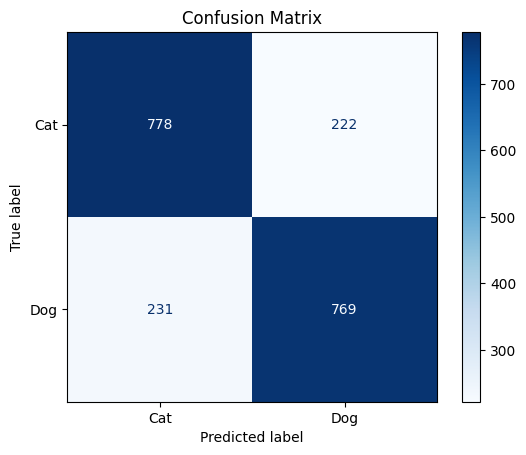

In [35]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat","Dog"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

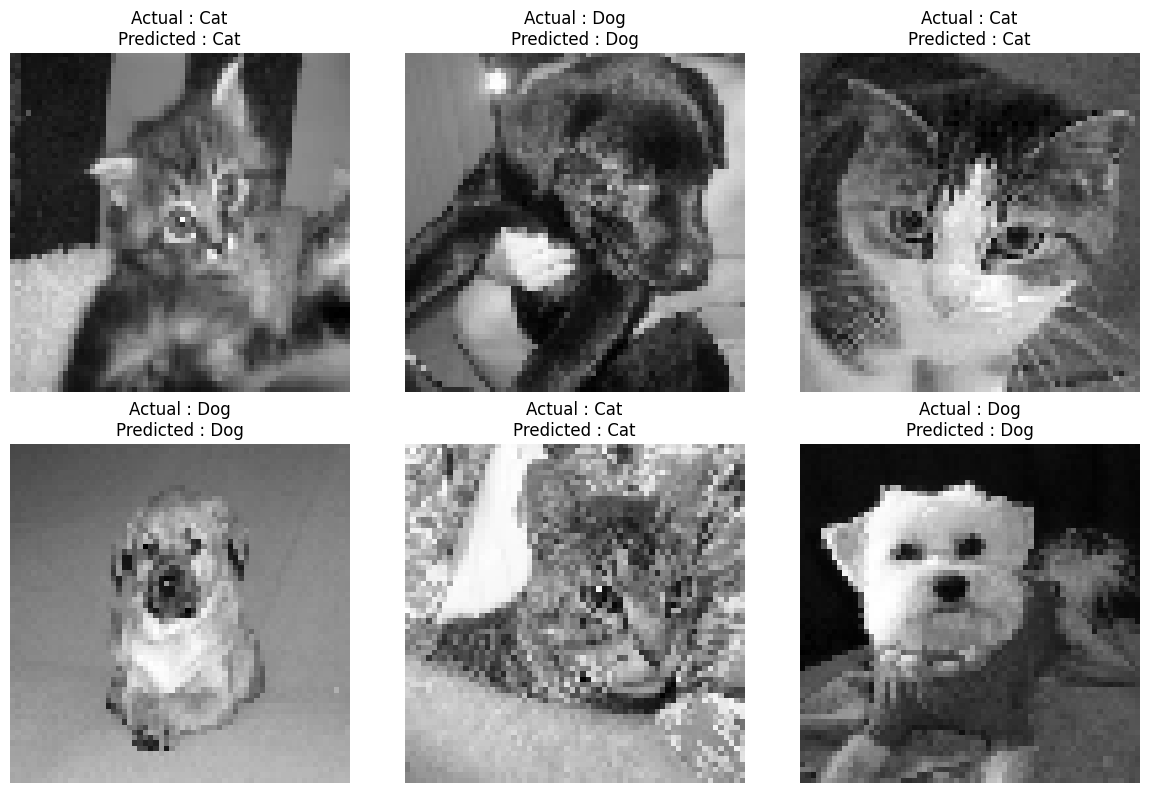

In [36]:
plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(img_test[i], cmap="gray")

    actual = "Cat" if y_test[i] == 0 else "Dog"
    predicted = "Cat" if y_pred[i] == 0 else "Dog"

    plt.title(f"Actual : {actual}\nPredicted : {predicted}")

    plt.axis("off")

plt.tight_layout()

plt.show()